# 📓 L6 Colab 1 — OLAP & Insight Generation (Olist)

Legge i CSV esportati dal Data Warehouse Olist e esegue le 4 operazioni OLAP fondamentali:
**Roll-Up, Drill-Down, Slice, Dice** + calcolo KPI e grafici.

**Input:** `consegna/9_exported_from_db/` — i CSV del DW
**Output:** `L6_out/` — KPI, insights JSON, grafici PNG

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json, os
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 4)

# ── Percorsi ──────────────────────────────────────────────────────
# Adatta CSV_PATH alla cartella dei tuoi CSV esportati
CSV_PATH = Path('../9_exported_from_db/')
OUT_PATH = Path('L6_out/')
OUT_PATH.mkdir(parents=True, exist_ok=True)
(OUT_PATH / 'bi').mkdir(exist_ok=True)

print('Paths OK')

Paths OK


In [2]:
# ── Carica i CSV del DW ───────────────────────────────────────────
import glob

def load_csv(pattern):
    files = sorted(glob.glob(str(CSV_PATH / pattern)))
    if not files:
        raise FileNotFoundError(f'Nessun file trovato per: {pattern}')
    return pd.read_csv(files[-1])   # prende il più recente

fact   = load_csv('fact_sales_*.csv')
dim_c  = load_csv('dim_customer_*.csv')
dim_d  = load_csv('dim_date_*.csv')
dim_p  = load_csv('dim_product_*.csv')
dim_s  = load_csv('dim_seller_*.csv')
dim_pt = load_csv('dim_payment_type_*.csv')

print(f'fact_sales:      {len(fact):,} righe')
print(f'dim_customer:    {len(dim_c):,} righe')
print(f'dim_date:        {len(dim_d):,} righe')
print(f'dim_product:     {len(dim_p):,} righe')
print(f'dim_seller:      {len(dim_s):,} righe')
print(f'dim_payment_type:{len(dim_pt):,} righe')

fact_sales:      112,650 righe
dim_customer:    99,441 righe
dim_date:        634 righe
dim_product:     32,951 righe
dim_seller:      3,095 righe
dim_payment_type:5 righe


In [3]:
# ── Wide table (denormalizzata) per le analisi OLAP ───────────────
# Join fact con le dimensioni principali

wide = (
    fact
    .merge(dim_d,  on='date_id',    how='left')
    .merge(dim_c,  on='customer_id', how='left')
    .merge(dim_p,  on='product_id',  how='left')
    .merge(dim_s,  on='seller_id',   how='left')
    .merge(dim_pt, on='payment_type_id', how='left')
)

# Colonna revenue principale
wide['revenue'] = wide['price'] + wide['freight_value']

print(f'Wide table: {len(wide):,} righe x {wide.shape[1]} colonne')
print(wide.dtypes[['year','quarter','month','customer_state','product_category_name_english','revenue']].to_string())

Wide table: 112,650 righe x 47 colonne
year                               int64
quarter                            int64
month                              int64
customer_state                    object
product_category_name_english     object
revenue                          float64


## 1. OLAP — Roll-Up
**Roll-Up:** aggrega i dati verso un livello gerarchico superiore.

Gerarchia temporale: `month → quarter → year`

Domanda di business: *Come è evoluto il fatturato anno per anno?*


=== ROLL-UP — Anno ===
 year      revenue  n_ordini  avg_price  avg_review
 2016   55631.0984       312 130.762270    3.552486
 2017 6843978.4534     44579 115.442046    4.053753
 2018 8300831.7028     53775 115.083598    4.022672


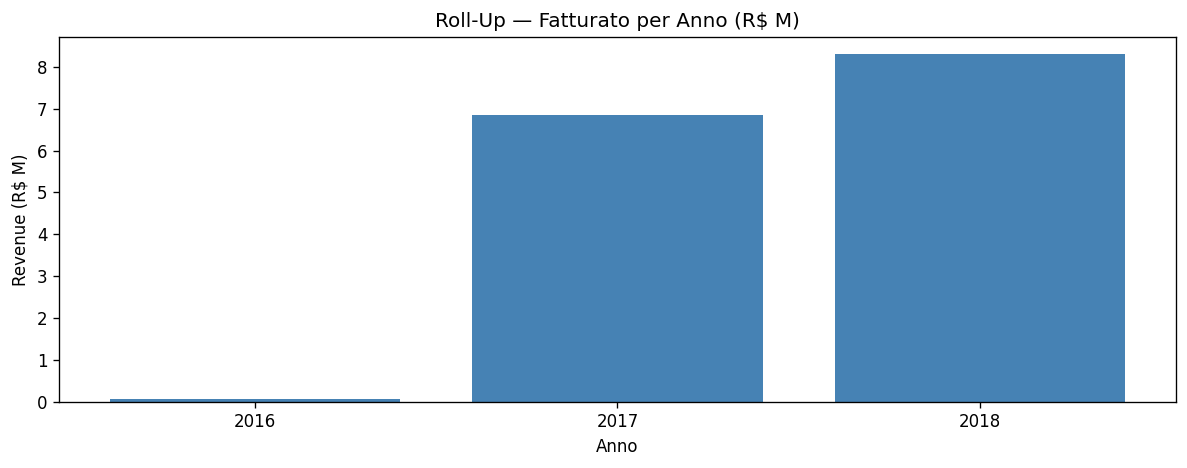

Grafico salvato: rollup_year.png


In [4]:
# ── Roll-Up: month → quarter → year ───────────────────────────────

rollup_year = (
    wide.groupby('year', as_index=False)
        .agg(
            revenue    = ('revenue', 'sum'),
            n_ordini   = ('order_id', 'nunique'),
            avg_price  = ('price', 'mean'),
            avg_review = ('review_score', 'mean')
        )
        .sort_values('year')
)

rollup_quarter = (
    wide.groupby(['year','quarter'], as_index=False)
        .agg(revenue=('revenue','sum'), n_ordini=('order_id','nunique'))
        .sort_values(['year','quarter'])
)

rollup_month = (
    wide.groupby(['year','month','month_name'], as_index=False)
        .agg(revenue=('revenue','sum'), n_ordini=('order_id','nunique'))
        .sort_values(['year','month'])
)

print('\n=== ROLL-UP — Anno ===')
print(rollup_year.to_string(index=False))

# Grafico
fig, ax = plt.subplots()
ax.bar(rollup_year['year'].astype(str), rollup_year['revenue']/1e6, color='steelblue')
ax.set_title('Roll-Up — Fatturato per Anno (R$ M)')
ax.set_ylabel('Revenue (R$ M)')
ax.set_xlabel('Anno')
plt.tight_layout()
plt.savefig(OUT_PATH / 'rollup_year.png')
plt.show()
print('Grafico salvato: rollup_year.png')

## 2. OLAP — Drill-Down
**Drill-Down:** scende nella gerarchia verso il dettaglio.

Gerarchia: `year → quarter → month` (per il 2018)

Domanda di business: *Come si distribuisce il fatturato del 2018 per trimestre e mese?*

=== DRILL-DOWN 2018 — Trimestre ===
 quarter      revenue  n_ordini
       1 3165582.9830     21102
       2 3180161.5510     19947
       3 1955087.1688     12726

=== DRILL-DOWN 2018 — Mese ===
month_name      revenue  n_ordini
   January 1078416.8892      7220
  February  965723.8010      6694
     March 1121442.2928      7188
     April 1105551.9594      6934
       May 1094605.9278      6853
      June  980003.6638      6160
      July  999728.7022      6273
    August  955192.0066      6452
 September     166.4600         1


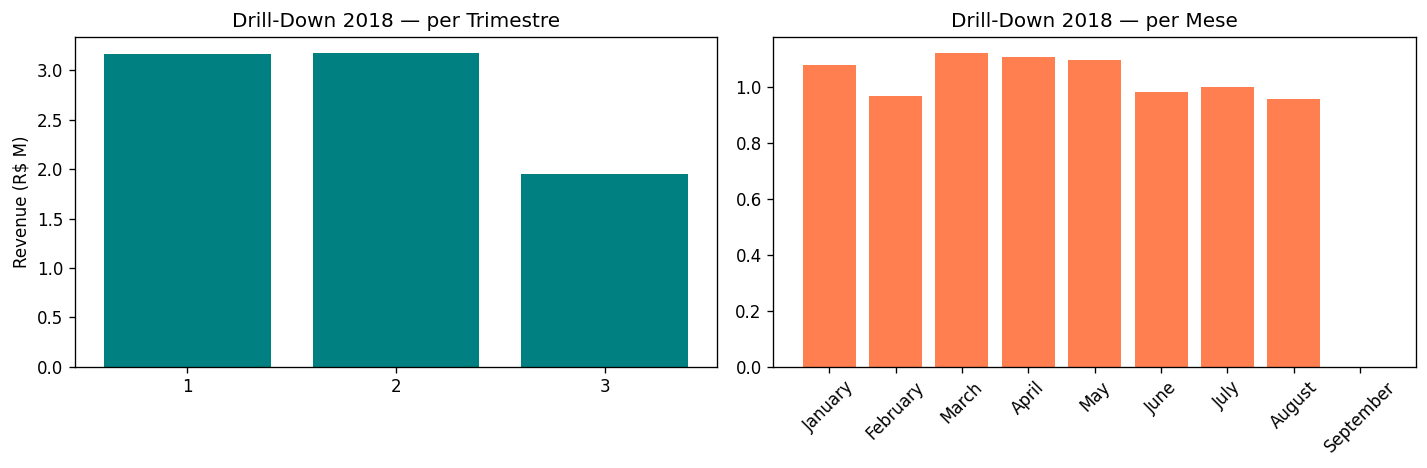

In [5]:
# ── Drill-Down: anno 2018 → trimestre → mese ─────────────────────

drill = wide[wide['year'] == 2018].copy()

drill_q = (
    drill.groupby('quarter', as_index=False)
         .agg(revenue=('revenue','sum'), n_ordini=('order_id','nunique'))
         .sort_values('quarter')
)

drill_m = (
    drill.groupby(['month','month_name'], as_index=False)
         .agg(revenue=('revenue','sum'), n_ordini=('order_id','nunique'))
         .sort_values('month')
)

print('=== DRILL-DOWN 2018 — Trimestre ===')
print(drill_q.to_string(index=False))
print('\n=== DRILL-DOWN 2018 — Mese ===')
print(drill_m[['month_name','revenue','n_ordini']].to_string(index=False))

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].bar(drill_q['quarter'].astype(str), drill_q['revenue']/1e6, color='teal')
axes[0].set_title('Drill-Down 2018 — per Trimestre')
axes[0].set_ylabel('Revenue (R$ M)')
axes[1].bar(drill_m['month_name'], drill_m['revenue']/1e6, color='coral')
axes[1].set_title('Drill-Down 2018 — per Mese')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUT_PATH / 'drilldown_2018.png')
plt.show()

## 3. OLAP — Slice
**Slice:** fissa il valore di UNA dimensione e analizza le altre.

Qui: `customer_state = 'SP'` (São Paulo)

Domanda di business: *Come performa il mercato di São Paulo?*

=== SLICE — São Paulo (SP) ===
Righe nel subcubo: 47,449
Revenue totale:    R$ 5,730,357
N. ordini unici:   41,375
Review media:      4.13
Ritardo medio:     -11.2 giorni


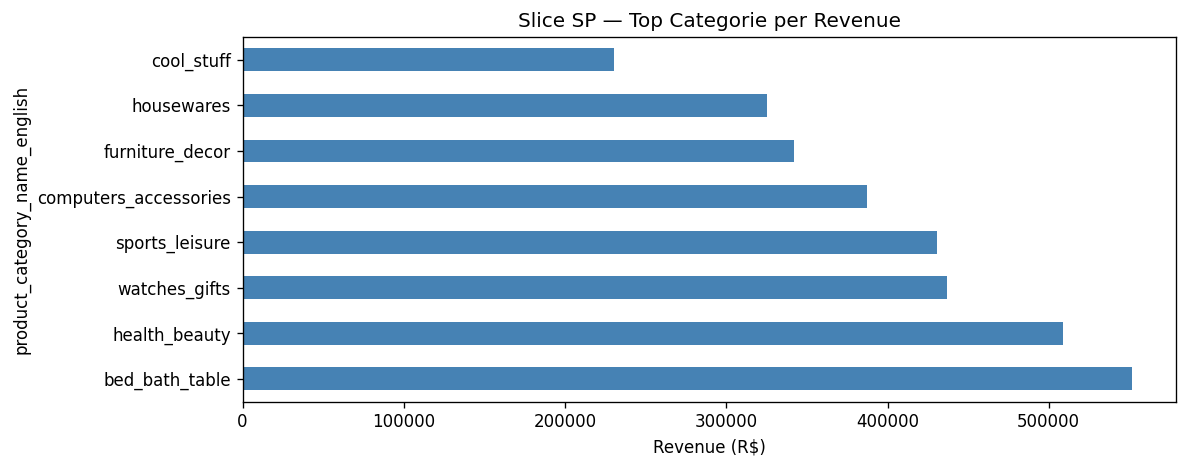

In [6]:
# ── Slice: customer_state = 'SP' ─────────────────────────────────

slice_sp = wide[wide['customer_state'] == 'SP'].copy()

print(f'=== SLICE — São Paulo (SP) ===')
print(f'Righe nel subcubo: {len(slice_sp):,}')
print(f'Revenue totale:    R$ {slice_sp["revenue"].sum():,.0f}')
print(f'N. ordini unici:   {slice_sp["order_id"].nunique():,}')
print(f'Review media:      {slice_sp["review_score"].mean():.2f}')
print(f'Ritardo medio:     {slice_sp["delivery_delay_days"].mean():.1f} giorni')

# Top categorie in SP
top_cat_sp = (
    slice_sp.groupby('product_category_name_english')['revenue']
            .sum().sort_values(ascending=False).head(8)
)

fig, ax = plt.subplots(figsize=(10,4))
top_cat_sp.plot.barh(ax=ax, color='steelblue')
ax.set_title('Slice SP — Top Categorie per Revenue')
ax.set_xlabel('Revenue (R$)')
plt.tight_layout()
plt.savefig(OUT_PATH / 'slice_sp.png')
plt.show()

## 4. OLAP — Dice
**Dice:** filtra su DUE o più dimensioni simultaneamente.

Qui: `customer_state = 'SP'` AND `year = 2018`

Domanda di business: *Com'è il mercato SP nel 2018, per categoria?*

=== DICE — SP AND 2018 ===
Righe nel subcubo: 27,279
Revenue totale:    R$ 3,292,702

Top categorie nel subcubo SP+2018:
product_category_name_english
health_beauty            336179.9868
bed_bath_table           313490.2734
watches_gifts            261118.3636
sports_leisure           240007.6084
computers_accessories    236874.9544
housewares               206612.7384
furniture_decor          176957.4838
auto                     136879.9990
baby                     105110.7292
cool_stuff                92587.9898


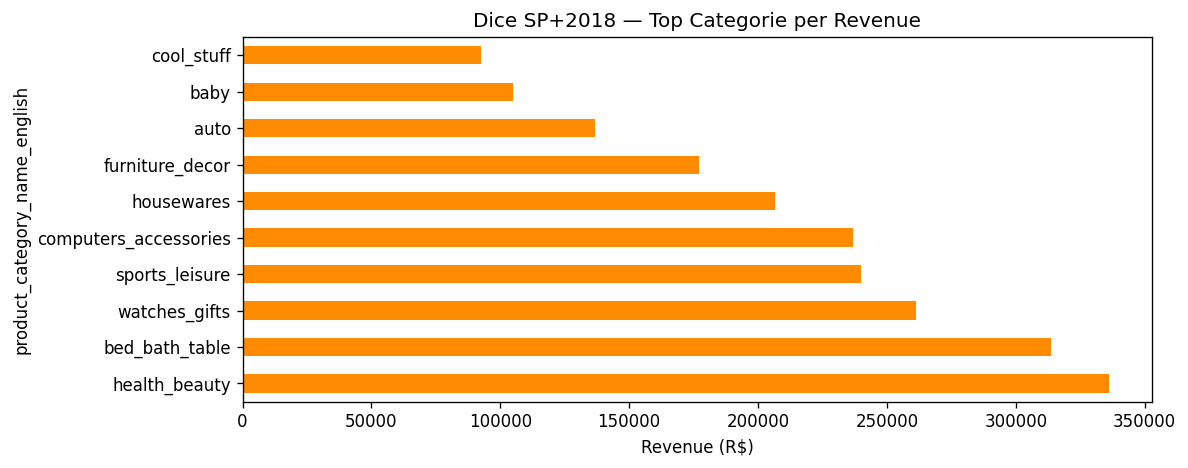

In [7]:
# ── Dice: SP AND 2018 ────────────────────────────────────────────

dice = wide[
    (wide['customer_state'] == 'SP') &
    (wide['year'] == 2018)
].copy()

print(f'=== DICE — SP AND 2018 ===')
print(f'Righe nel subcubo: {len(dice):,}')
print(f'Revenue totale:    R$ {dice["revenue"].sum():,.0f}')

# Revenue per categoria nel subcubo
dice_cat = (
    dice.groupby('product_category_name_english')['revenue']
        .sum().sort_values(ascending=False).head(10)
)
print('\nTop categorie nel subcubo SP+2018:')
print(dice_cat.to_string())

fig, ax = plt.subplots(figsize=(10,4))
dice_cat.plot.barh(ax=ax, color='darkorange')
ax.set_title('Dice SP+2018 — Top Categorie per Revenue')
ax.set_xlabel('Revenue (R$)')
plt.tight_layout()
plt.savefig(OUT_PATH / 'dice_sp_2018.png')
plt.show()

## 5. KPI e Insights

In [8]:
# ── KPI globali ──────────────────────────────────────────────────

kpis = {
    'total_revenue':      round(float(wide['revenue'].sum()), 2),
    'total_sales':        int(len(wide)),
    'unique_orders':      int(wide['order_id'].nunique()),
    'unique_customers':   int(wide['customer_id'].nunique()),
    'avg_price':          round(float(wide['price'].mean()), 2),
    'avg_review':         round(float(wide['review_score'].mean()), 2),
    'avg_delay_days':     round(float(wide['delivery_delay_days'].mean()), 2),
    'top_state':          wide.groupby('customer_state')['revenue'].sum().idxmax(),
    'top_category':       wide.groupby('product_category_name_english')['revenue'].sum().idxmax(),
    'top_payment':        wide.groupby('payment_type')['revenue'].sum().idxmax(),
}

print('=== KPI GLOBALI ===')
for k,v in kpis.items():
    print(f'  {k}: {v}')

with open(OUT_PATH / 'bi' / 'kpis.json', 'w') as f:
    json.dump(kpis, f, indent=2, ensure_ascii=False)
print('\nKPI salvati -> L6_out/bi/kpis.json')

=== KPI GLOBALI ===
  total_revenue: 15200441.25
  total_sales: 112650
  unique_orders: 98666
  unique_customers: 98666
  avg_price: 115.3
  avg_review: 4.04
  avg_delay_days: -12.03
  top_state: SP
  top_category: health_beauty
  top_payment: credit_card

KPI salvati -> L6_out/bi/kpis.json


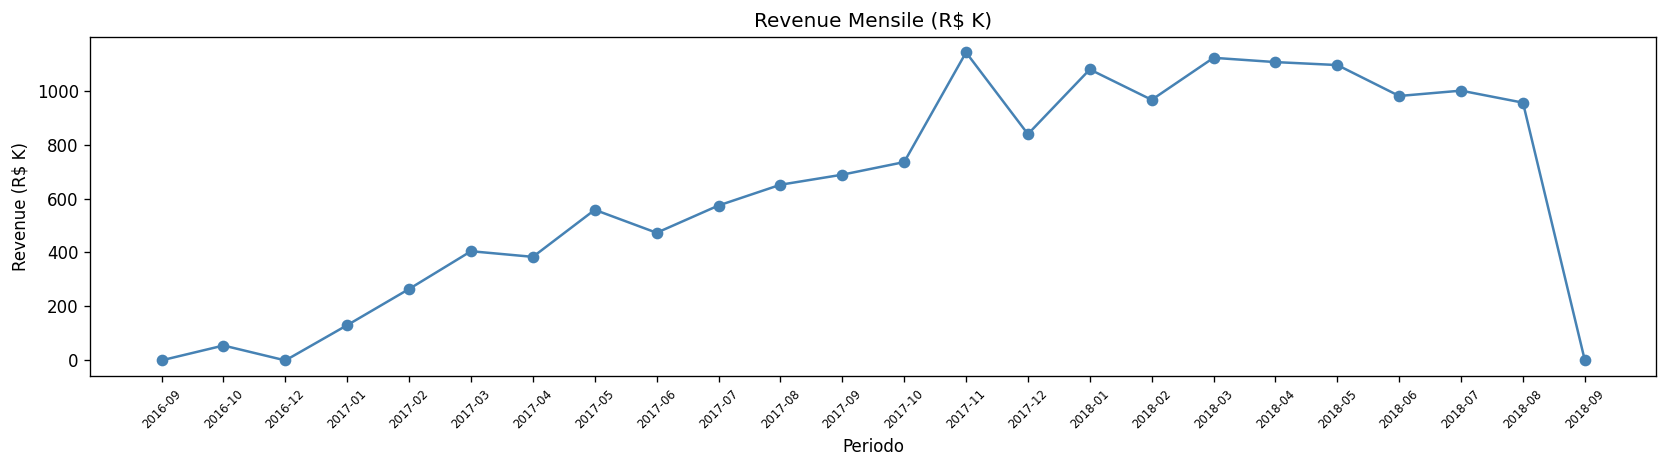

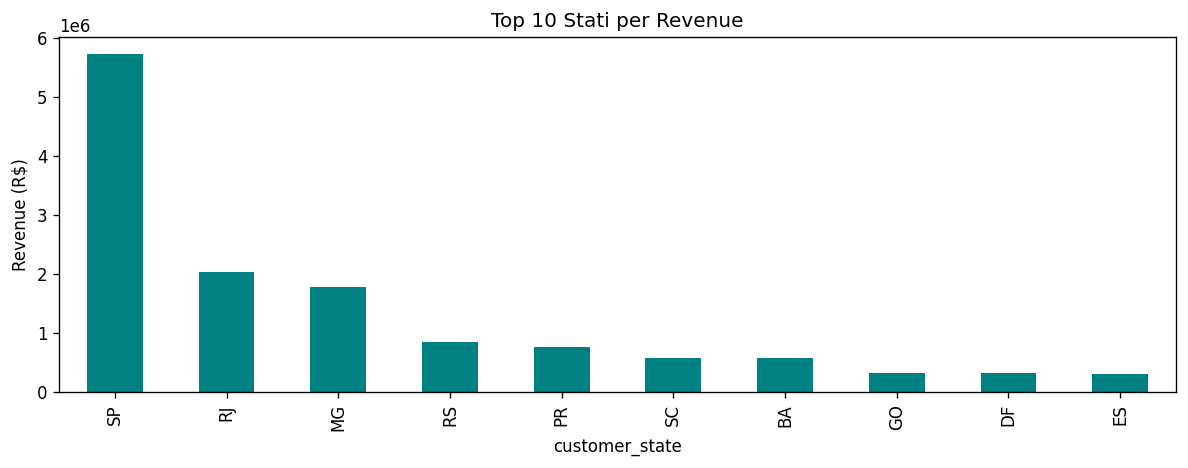

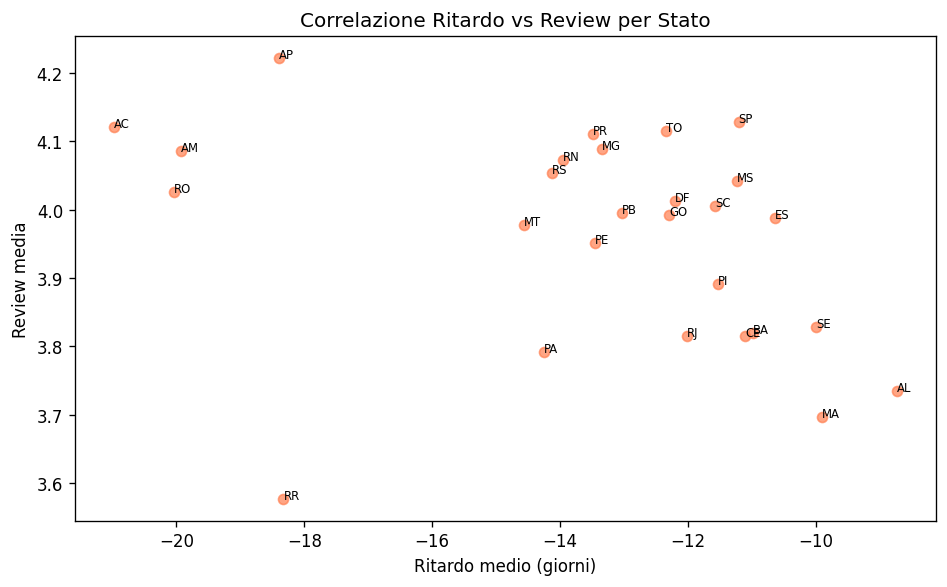

Grafici salvati in L6_out/


In [9]:
# ── Insight 1: Revenue trend mensile ─────────────────────────────
monthly = (
    wide.groupby(['year','month','month_name'], as_index=False)
        .agg(revenue=('revenue','sum'), n_ordini=('order_id','nunique'))
        .sort_values(['year','month'])
)
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(monthly['period'], monthly['revenue']/1e3, marker='o', linewidth=1.5, color='steelblue')
ax.set_title('Revenue Mensile (R$ K)')
ax.set_xlabel('Periodo')
ax.set_ylabel('Revenue (R$ K)')
plt.xticks(rotation=45, fontsize=7)
plt.tight_layout()
plt.savefig(OUT_PATH / 'trend_mensile.png')
plt.show()

# ── Insight 2: Top 10 stati per revenue ──────────────────────────
state_rev = (
    wide.groupby('customer_state')['revenue']
        .sum().sort_values(ascending=False).head(10)
)
fig, ax = plt.subplots(figsize=(10,4))
state_rev.plot.bar(ax=ax, color='teal')
ax.set_title('Top 10 Stati per Revenue')
ax.set_ylabel('Revenue (R$)')
plt.tight_layout()
plt.savefig(OUT_PATH / 'top_states.png')
plt.show()

# ── Insight 3: Correlazione ritardo-review ───────────────────────
state_stats = (
    wide.groupby('customer_state')
        .agg(avg_delay=('delivery_delay_days','mean'),
             avg_review=('review_score','mean'))
        .reset_index()
)
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(state_stats['avg_delay'], state_stats['avg_review'], alpha=0.7, color='coral')
for _, r in state_stats.iterrows():
    ax.annotate(r['customer_state'], (r['avg_delay'], r['avg_review']), fontsize=7)
ax.set_xlabel('Ritardo medio (giorni)')
ax.set_ylabel('Review media')
ax.set_title('Correlazione Ritardo vs Review per Stato')
plt.tight_layout()
plt.savefig(OUT_PATH / 'corr_delay_review.png')
plt.show()
print('Grafici salvati in L6_out/')

In [10]:
# ── Salva wide table per Colab 2 ─────────────────────────────────
cols_export = [
    'sale_id','order_id','date_id','customer_id','product_id','seller_id','payment_type_id',
    'year','quarter','month','month_name',
    'customer_state','product_category_name_english','payment_type',
    'price','freight_value','revenue','payment_value',
    'delivery_delay_days','delivery_lead_days','review_score'
]
wide[cols_export].to_csv(OUT_PATH / 'bi' / 'orders_wide.csv', index=False)
print(f'Wide table salvata -> L6_out/bi/orders_wide.csv ({len(wide):,} righe)')

Wide table salvata -> L6_out/bi/orders_wide.csv (112,650 righe)
